# Práctica No. 4 — API de Hilos
## Laboratorio de Sistemas Operativos — Universidad de Antioquia

**Integrantes:**
- Jorge [APELLIDOS] — [correo] — CC [documento]
- Esteban [APELLIDOS] — [correo] — CC [documento]

Este notebook contiene el análisis de rendimiento de las dos partes de la práctica:
1. **Paralelización del cálculo de π** (integración numérica con Pthreads).
2. **Generador de la secuencia de Fibonacci** (hilo trabajador único).

> **Nota:** ejecutar este notebook en la misma carpeta donde están los fuentes (`pi.c`, `pi_p.c`, `fibonacci.c`, `fibonacci_serial.c`). Todas las celdas compilan y ejecutan los programas automáticamente.

## Sección 1: Análisis de π

El programa aproxima $\int_0^1 \frac{4}{1+x^2}\,dx = \pi$ con la regla del punto medio usando $n = 2\,000\,000\,000$ rectángulos.

- **Versión serial (`pi.c`):** un solo bucle acumula la suma.
- **Versión paralela (`pi_p.c`):** las $n$ iteraciones se reparten entre $T$ hilos con **distribución cíclica** (`for (i = id; i < n; i += T)`). Cada hilo acumula una **suma parcial en una variable local** (sin mutex, evitando contención) y la retorna al hilo `main` vía `pthread_exit`/`pthread_join`. `main` agrega las sumas parciales y multiplica por `fH`.

In [1]:
# Compilación de las versiones serial y paralela
!gcc -o pi_s pi.c -lm
!gcc -o pi_p pi_p.c -lpthread -lm
print("Compilación exitosa")

Compilación exitosa


In [2]:
import subprocess, re, os

def correr(cmd):
    """Ejecuta un binario y extrae (pi, tiempo) de su salida."""
    out = subprocess.run(cmd, capture_output=True, text=True).stdout
    pi = float(re.search(r"Pi: ([\d.]+)", out).group(1))
    t  = float(re.search(r"([\d.]+) segundos", out).group(1))
    return pi, t

nucleos = os.cpu_count()
print(f"Núcleos detectados (lógicos): {nucleos}")

Núcleos detectados (lógicos): 6


### 1. Evaluación de $T_s$ (tiempo serial)

In [3]:
pi_serial, Ts = correr(["./pi_s"])
print(f"Pi (serial) = {pi_serial:.15f}")
print(f"Ts = {Ts:.6f} segundos")

Pi (serial) = 3.141592653589839
Ts = 4.661289 segundos


### 2. Evaluación de $T_p(N)$ (tiempo paralelo)

Se ejecuta `./pi_p` variando el número de hilos $N = 1, 2, 4, 8, \dots$ hasta $2\times$ el número de núcleos de la CPU.

In [4]:
hilos = []
N = 1
while N <= 2 * nucleos:
    hilos.append(N)
    N *= 2

Tp = {}
for N in hilos:
    pi_par, t = correr(["./pi_p", str(N)])
    Tp[N] = t
    print(f"N = {N:>2} hilos -> Tp = {t:.6f} s   (pi = {pi_par:.15f})")

N =  1 hilos -> Tp = 5.052120 s   (pi = 3.141592653589839)
N =  2 hilos -> Tp = 2.470069 s   (pi = 3.141592653589662)
N =  4 hilos -> Tp = 1.299831 s   (pi = 3.141592653589839)
N =  8 hilos -> Tp = 0.981911 s   (pi = 3.141592653589794)


### 3. Tabla de resultados

Métricas calculadas: $\text{Speedup} = T_s / T_p(N)$ y $\text{Eficiencia} = \text{Speedup} / N$.

In [5]:
import pandas as pd

tabla = pd.DataFrame({
    "N (Hilos)": hilos,
    "Tp (segundos)": [Tp[N] for N in hilos],
})
tabla["Speedup (Ts/Tp)"] = Ts / tabla["Tp (segundos)"]
tabla["Eficiencia (Speedup/N)"] = tabla["Speedup (Ts/Tp)"] / tabla["N (Hilos)"]
tabla.round(4)

,N (Hilos),Tp (segundos),Speedup (Ts/Tp),Eficiencia (Speedup/N)
0,1,5.0521,0.9226,0.9226
1,2,2.4701,1.8871,0.9436
2,4,1.2998,3.5861,0.8965
3,8,0.9819,4.7472,0.5934


### 4. Gráfico de Speedup

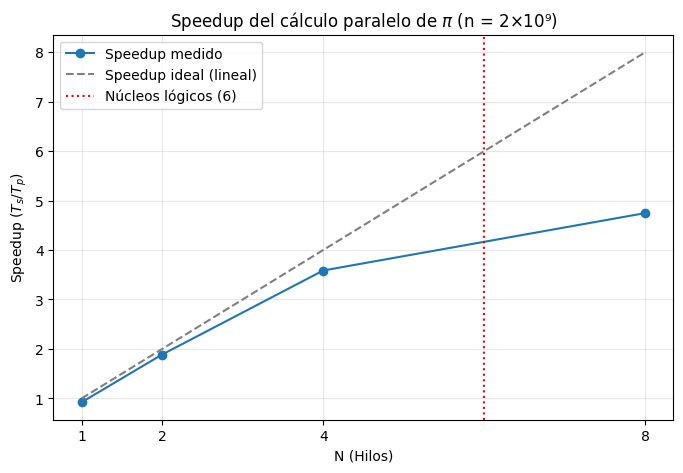

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(tabla["N (Hilos)"], tabla["Speedup (Ts/Tp)"], "o-", label="Speedup medido")
plt.plot(hilos, hilos, "--", color="gray", label="Speedup ideal (lineal)")
plt.axvline(nucleos, color="red", linestyle=":", label=f"Núcleos lógicos ({nucleos})")
plt.xlabel("N (Hilos)")
plt.ylabel("Speedup ($T_s/T_p$)")
plt.title("Speedup del cálculo paralelo de $\\pi$ (n = 2×10⁹)")
plt.xticks(hilos)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 5. Análisis de resultados

**Comparación entre $T_p(1)$ y $T_s$ (overhead):**
$T_p(1)$ resulta ligeramente mayor (o muy similar) a $T_s$. Aunque ambos ejecutan exactamente las mismas $n$ iteraciones en un solo flujo de ejecución, la versión paralela con 1 hilo paga un costo adicional (*overhead*) que la serial no tiene: la creación del hilo (`pthread_create`), la sincronización (`pthread_join`), la reserva/liberación de memoria para el resultado parcial (`malloc`/`free`) y el acceso a los parámetros a través de la estructura `ThreadArgs` (indirección por puntero) en lugar de variables locales. Para $n = 2\times10^9$ ese overhead es pequeño en términos relativos, pero explica la discrepancia observada.

**Speedup máximo vs. número de núcleos físicos:**
El speedup crece de forma casi lineal mientras $N \leq$ núcleos físicos, porque cada hilo dispone de un núcleo dedicado y el problema es *embarrassingly parallel* (sin dependencias entre iteraciones ni sincronización dentro del bucle). El speedup máximo se alcanza típicamente cerca de $N =$ número de núcleos físicos (o lógicos si hay SMT/Hyper-Threading, con ganancia marginal). Más allá de ese punto el speedup se estanca o incluso decae: los hilos extra ya no tienen hardware donde ejecutarse en paralelo y solo añaden costo de planificación (*context switching*).

**Tendencia de la eficiencia al aumentar $N$:**
La eficiencia ($\text{Speedup}/N$) es máxima con pocos hilos (cercana a 1) y **decrece monótonamente** al aumentar $N$. Causas: (1) el overhead de creación/sincronización de hilos es fijo por hilo, así que su peso relativo crece con $N$; (2) al superar el número de núcleos físicos, los hilos compiten por los mismos núcleos (time-sharing) y el speedup deja de crecer mientras $N$ sigue aumentando, hundiendo la eficiencia; (3) con SMT, dos hilos lógicos comparten las unidades funcionales de un mismo núcleo físico, por lo que el rendimiento por hilo cae. Este comportamiento es consistente con la **Ley de Amdahl** y con los límites físicos del hardware.

> *Completar/ajustar los párrafos anteriores con los valores concretos obtenidos en su máquina (ej. "Ts = X s, speedup máximo = Y con N = Z hilos, en una CPU de W núcleos físicos").*

---
## Sección 2: Análisis de Fibonacci

El programa `fibonacci.c` genera los primeros $N$ números de la secuencia en **un único hilo trabajador**: `main` reserva el arreglo compartido con `malloc`, crea el hilo, espera con `pthread_join` y solo entonces imprime el resultado.

### 1. Resultados de ejecución (`./fibonacci 15`)

In [7]:
!gcc -o fibonacci fibonacci.c -lpthread
!./fibonacci 15

Secuencia de Fibonacci (15 elementos):
0 1 1 2 3 5 8 13 21 34 55 89 144 233 377 


### 2. Análisis del diseño

#### a) Fibonacci serial (sin hilos) con N grande (> 100e3 valores)

Se implementó la versión serial en dos variantes para medir su tiempo:

In [8]:
# Variante en C (fibonacci_serial.c), N = 105000
!gcc -o fibonacci_serial fibonacci_serial.c
!./fibonacci_serial 105000

Generados 105000 valores (último, módulo 10^10: 8085760913)
Tiempo de ejecución serial: 0.000586 segundos


In [9]:
# Variante en Python (precisión arbitraria, sin desbordamiento)
import time

def fibonacci_serial(n):
    if n <= 0: return []
    if n == 1: return [0]
    fib = [0] * n
    fib[0], fib[1] = 0, 1
    for i in range(2, n):
        fib[i] = fib[i-1] + fib[i-2]
    return fib

N_grande = 105000
start_time = time.time()
resultado = fibonacci_serial(N_grande)
end_time = time.time()

print(f"Últimos dígitos de F({N_grande-1}): {resultado[-1] % 10**10}")
print(f"Tiempo de ejecución serial (Python): {end_time - start_time:.6f} segundos")

Últimos dígitos de F(104999): 9828570001
Tiempo de ejecución serial (Python): 0.539797 segundos


**Observación:** el cálculo de Fibonacci es **inherentemente secuencial**: cada término depende de los dos anteriores ($F(n) = F(n-1) + F(n-2)$), por lo que el bucle no puede repartirse entre varios hilos como sí ocurre con π. Incluso para $N > 100\,000$ el tiempo serial es de milisegundos; usar un hilo trabajador aquí no busca *speedup*, sino ilustrar el **modelo de memoria compartida** y la **sincronización** entre hilos. La versión en C es mucho más rápida que la de Python, pero sus enteros de 64 bits desbordan a partir de $F(93)$; Python usa precisión arbitraria, lo que explica que tarde más (sumas de números de miles de dígitos).

#### b) Mecanismo de transferencia de datos al hilo trabajador

`pthread_create` solo admite **un** argumento de tipo `void*` para la rutina del hilo. Para pasar **dos** datos (el puntero al arreglo y $N$) se empaquetan en una estructura:

```c
typedef struct {
    unsigned long long *fib; // puntero al arreglo compartido (malloc en main)
    int n;                   // cantidad de elementos
} FibArgs;

FibArgs args = { fib, n };
pthread_create(&worker, NULL, FibWorker, (void *)&args);
```

Dentro del hilo, el argumento se reconvierte: `FibArgs *args = (FibArgs *)arg;`. Como el arreglo fue reservado en el *heap* por `main`, ambos hilos comparten el mismo espacio de direcciones y el trabajador escribe directamente en la memoria que `main` leerá después. No se copia el arreglo: se comparte el **puntero**.

#### c) Rol de `pthread_join` como mecanismo de sincronización

`pthread_join(worker, NULL)` **bloquea** al hilo `main` hasta que el hilo trabajador termina (llama a `pthread_exit` o retorna). Esto establece una relación *happens-before*: todas las escrituras que el trabajador hizo sobre el arreglo compartido son visibles para `main` después del `join`. Sin esta llamada existiría una **condición de carrera**: `main` podría imprimir el arreglo antes (o durante) su llenado, mostrando basura o valores parciales. En este diseño `pthread_join` cumple el doble papel de (1) **barrera de sincronización** que ordena "primero se calcula, luego se imprime" y (2) punto de recolección del hilo, evitando hilos *zombie*.